
# Tutorial: Predicción de Desempeño de Aulas con Redes Neuronales

Objetivo es enseñar a los estudiantes cómo abordar un problema de clasificación del mundo real utilizando redes neuronales con Python, TensorFlow y Keras.

### El Problema

Tenemos un conjunto de datos que contiene el seguimiento realizado a las aulas virtuales de los docentes. Nuestro objetivo es construir un modelo de inteligencia artificial que pueda **predecir la valoración de desempeño de un aula** basándose en sus características (ej. tipo de curso, plantilla, interacción, etc.).

### Metodología

Seguiremos un flujo de trabajo estándar de Machine Learning:

1.  **Configuración del Entorno:** Importar las librerías necesarias.
2.  **Análisis Exploratorio de Datos (EDA):** Cargar y entender nuestros datos.
3.  **Pre-procesamiento de Datos:** Limpiar y preparar los datos para el modelo.
4.  **Construcción del Modelo:** Diseñar la arquitectura de nuestra red neuronal.
5.  **Entrenamiento del Modelo:** Enseñar al modelo a reconocer patrones en los datos.
6.  **Evaluación del Modelo:** Medir qué tan bueno es nuestro modelo para hacer predicciones.
7.  **Predicción en Nuevos Datos:** Usar el modelo entrenado para predecir el desempeño de un aula nueva.



## Paso 1: Configuración del Entorno

Lo primero que necesitamos es importar todas las herramientas (librerías) que usaremos en nuestro proyecto. Si alguna de estas librerías no está instalada, puedes instalarla ejecutando `pip install <nombre_libreria>` en tu terminal.


In [1]:

# --- Librerías para manipulación y análisis de datos ---
import pandas as pd
import numpy as np

# --- Librerías para visualización ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Librerías de Scikit-Learn para pre-procesamiento y evaluación ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Librerías de TensorFlow y Keras para la Red Neuronal ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Configuraciones adicionales ---
import warnings
warnings.filterwarnings('ignore') # Para ignorar advertencias molestas

print("¡Librerías importadas exitosamente!")


¡Librerías importadas exitosamente!



## Paso 2: Análisis Exploratorio de Datos (EDA)

En esta fase, nuestro objetivo es "conocer" nuestros datos. ¿Qué información contienen? ¿Hay errores? ¿Cómo se distribuyen?

**Nota:** Asegúrase de que el archivo `data.xlsx` esté en la misma carpeta que este cuaderno de Jupyter.


In [34]:

# Cargamos el archivo de Excel en un DataFrame de Pandas
df = pd.read_excel("D:/UNIMINUTO/20252/UnidadC/UNIMINUTO/4.ELECTIVA_FIA/data.xlsx")

# Mostramos las primeras 5 filas para tener una primera impresión
print("Primeras 5 filas del dataset:")
df.head()


Primeras 5 filas del dataset:


,NRC,Periodo,Asignatura,Momento,Salon,Tipo,Id_Docente,Responsable,Sede_Docente,Ubicación,Tipo_Curso,Plantilla,Total_Alistamiento,Total_Ejecucion,Total_Curso,Valoracion,Email_Enviado
0,41-100,202441,Metodología de la Investigac,3,B1-104,PRESENCIAL,478259,AEMD,IBA,IBA,PD,INNOVAME,50.0,0.0,50.0,Desempeño insatisfactorio,-
1,41-101,202441,Formulación de Proyectos,1,B1-104,PRESENCIAL,662326,ESP,IBA,IBA,PD,INNOVAME,30.0,16.1,46.1,Desempeño insatisfactorio,SI
2,41-102,202441,Evaluación de Proyectos,2,B2-105,PRESENCIAL,662326,ESP,IBA,IBA,PD,INNOVAME,20.0,30.0,50.0,Desempeño insatisfactorio,-
3,41-104,202441,Gerencia del Conoc y la Tecnol,2,VIRTU,VIRTUAL,846904,ESP,IBA,IBA,PD,INNOVAME,50.0,35.0,85.0,Desempeño Bueno,-
4,41-56330,202441,Electiva,2,B1-104,PRESENCIAL,738598,ESP,IBA,IBA,PD,INNOVAME,50.0,40.0,90.0,Desempeño Bueno,-


In [19]:

# Obtenemos información general del dataset: columnas, tipos de datos y valores no nulos
print("Información general del dataset:")
df.info()


Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1266 entries, 0 to 1265
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NRC                 1266 non-null   object 
 1   Periodo             1266 non-null   int64  
 2   Asignatura          1266 non-null   object 
 3   Momento             1266 non-null   int64  
 4   Salon               1266 non-null   object 
 5   Tipo                1266 non-null   object 
 6   Id_Docente          1266 non-null   int64  
 7   Responsable         1266 non-null   object 
 8   Sede_Docente        1266 non-null   object 
 9   Longitud            0 non-null      float64
 10  Latitud             0 non-null      float64
 11  Ubicación           1266 non-null   object 
 12  Tipo_Curso          1266 non-null   object 
 13  Plantilla           1199 non-null   object 
 14  Total_Alistamiento  1266 non-null   float64
 15  Total_Ejecucion     12

In [20]:

# Obtenemos estadísticas descriptivas para las columnas numéricas
# Esto nos ayuda a entender la escala y distribución de los números
print("Estadísticas de las columnas numéricas:")
df.describe()


Estadísticas de las columnas numéricas:


,Periodo,Momento,Id_Docente,Longitud,Latitud,Total_Alistamiento,Total_Ejecucion,Total_Curso
count,1266.000000,1266.000000,1.266000e+03,0.0,0.0,1266.000000,1266.000000,1266.000000
mean,202416.515798,2.131912,4.770908e+06,NaN,NaN,44.966885,36.867022,81.833908
std,12.836774,0.858794,1.779538e+07,NaN,NaN,13.581813,12.812870,24.967704
min,202410.000000,1.000000,0.000000e+00,NaN,NaN,0.000000,0.000000,0.000000
25%,202412.750000,1.000000,4.395502e+05,NaN,NaN,49.230769,35.000000,85.000000
50%,202415.000000,2.000000,6.563590e+05,NaN,NaN,50.000000,40.000000,90.000000
75%,202415.000000,3.000000,8.669700e+05,NaN,NaN,50.000000,40.000000,90.000000
max,202485.000000,4.000000,9.339331e+07,NaN,NaN,50.000000,50.000000,100.000000


Distribución de la columna 'Valoracion':
Valoracion
Desempeño Bueno              899
Desempeño Excelente          210
No evaluada                   98
Desempeño Aceptable           30
Desempeño insatisfactorio     29
Name: count, dtype: int64


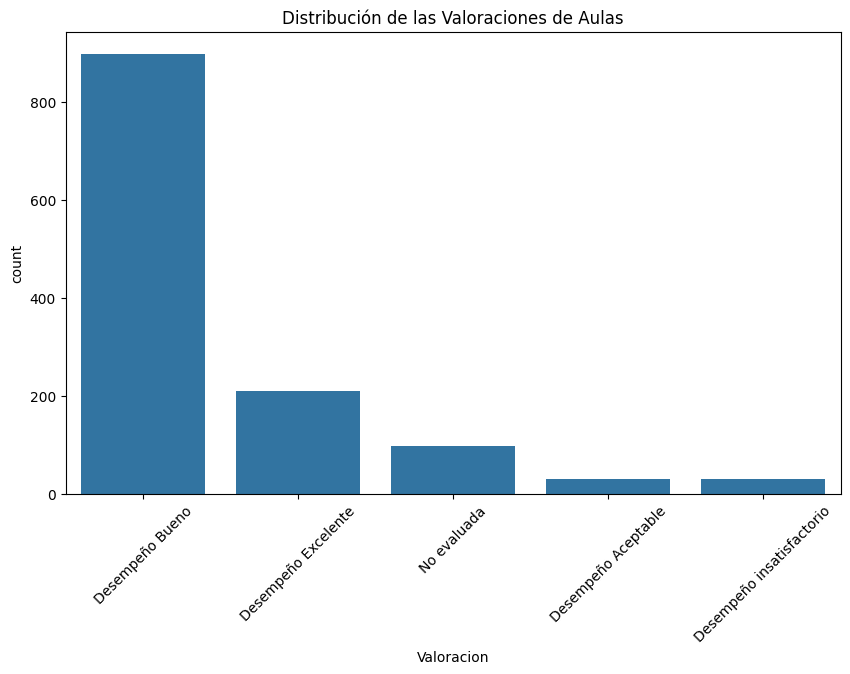

In [21]:

# Analizamos nuestra variable objetivo: 'Valoracion'
# ¿Cuántas categorías hay y cuántas aulas por categoría?
print("Distribución de la columna 'Valoracion':")
print(df['Valoracion'].value_counts())

# Visualicemos esto para que sea más claro
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Valoracion', order=df['Valoracion'].value_counts().index)
plt.title('Distribución de las Valoraciones de Aulas')
plt.xticks(rotation=45)
plt.show()



### Conclusiones del Análisis

1.  **Datos Completos:** La mayoría de las columnas no tienen valores nulos, excepto `Plantilla`.
2.  **Variable Objetivo:** Nuestra columna a predecir, `Valoracion`, tiene 5 categorías. Sin embargo, la categoría `No evaluada` no nos sirve para entrenar un modelo que prediga el desempeño, por lo que tendremos que eliminarla.
3.  **Desbalance de Clases:** Hay una gran cantidad de aulas con "Desempeño Bueno" en comparación con las otras categorías. Esto es muy importante, ya que el modelo podría aprender a predecir siempre "Bueno" y aun así tener una alta precisión. Tendremos que tener esto en cuenta al evaluar.



## Paso 3: Pre-procesamiento de Datos

Las redes neuronales, como la mayoría de los modelos de Machine Learning, necesitan que los datos estén en un formato numérico, limpio y estructurado. Este es uno de los pasos más importantes.

**Tareas a realizar:**
1.  **Limpieza:** Eliminar filas inútiles y manejar valores nulos.
2.  **Selección de Características:** Elegir qué columnas usaremos para predecir.
3.  **Codificación:** Convertir texto a números.
4.  **Normalización:** Poner todos los valores numéricos en una escala similar.
5.  **División de Datos:** Separar nuestros datos para entrenar y para probar el modelo.


In [38]:

# 1. Limpieza
print(f"Tamaño original del dataset: {df.shape[0]} filas")

# Eliminamos las filas donde la valoración es "No evaluada"
df_clean = df[df['Valoracion'] != 'No evaluada'].copy()

# Rellenamos los valores nulos en 'Plantilla' con una nueva categoría 'DESCONOCIDO'
df_clean['Plantilla'] = df_clean['Plantilla'].fillna('DESCONOCIDO')

print(f"Tamaño del dataset después de la limpieza: {df_clean.shape[0]} filas")


Tamaño original del dataset: 1266 filas
Tamaño del dataset después de la limpieza: 1168 filas


In [39]:

# 2. Selección de Características
# No todas las columnas son útiles. Por ejemplo, 'NRC' o 'Id_Docente' son identificadores únicos
# que no ayudan a generalizar. Elegimos un subconjunto de características.

features_to_use = [
    'Momento', 'Tipo', 'Tipo_Curso','Plantilla', 'Total_Alistamiento', 'Total_Ejecucion', 'Total_Curso'
]

target_variable = 'Valoracion'

X = df_clean[features_to_use]
y = df_clean[target_variable]

print("Características que usaremos (X):")
print(X.head())
print("Variable que predeciremos (y):")
print(y.head())


Características que usaremos (X):
   Momento        Tipo Tipo_Curso Plantilla  Total_Alistamiento  \
0        3  PRESENCIAL         PD  INNOVAME                50.0   
1        1  PRESENCIAL         PD  INNOVAME                30.0   
2        2  PRESENCIAL         PD  INNOVAME                20.0   
3        2     VIRTUAL         PD  INNOVAME                50.0   
4        2  PRESENCIAL         PD  INNOVAME                50.0   

   Total_Ejecucion  Total_Curso  
0              0.0         50.0  
1             16.1         46.1  
2             30.0         50.0  
3             35.0         85.0  
4             40.0         90.0  
Variable que predeciremos (y):
0    Desempeño insatisfactorio
1    Desempeño insatisfactorio
2    Desempeño insatisfactorio
3              Desempeño Bueno
4              Desempeño Bueno
Name: Valoracion, dtype: object


In [40]:

# 3. Codificación de Variables Categóricas
# Las redes neuronales no entienden texto como "PRESENCIAL" o "INNOVAME".
# Debemos convertirlos a números. Usaremos LabelEncoder.

# Copiamos X para no modificar el original
X_encoded = X.copy()

# Creamos un diccionario para guardar nuestros codificadores
label_encoders = {}

categorical_features = ['Tipo','Tipo_Curso', 'Plantilla']

for col in categorical_features:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    label_encoders[col] = le # Guardamos el codificador

# También codificamos nuestra variable objetivo 'y'
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

print("Características después de la codificación:")
print(X_encoded.head())
print("Variable objetivo después de la codificación:")
print(y_encoded[:5])


Características después de la codificación:
   Momento  Tipo  Tipo_Curso  Plantilla  Total_Alistamiento  Total_Ejecucion  \
0        3     0           0          1                50.0              0.0   
1        1     0           0          1                30.0             16.1   
2        2     0           0          1                20.0             30.0   
3        2     1           0          1                50.0             35.0   
4        2     0           0          1                50.0             40.0   

   Total_Curso  
0         50.0  
1         46.1  
2         50.0  
3         85.0  
4         90.0  
Variable objetivo después de la codificación:
[3 3 3 1 1]


In [41]:

# 4 y 5. División de Datos y Normalización

# Dividimos los datos: 80% para entrenar, 20% para probar.
# `stratify=y_encoded` es importante para mantener la proporción de clases en ambos conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalizamos las características numéricas
# Creamos el scaler y lo ajustamos SOLO con los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Aplicamos la misma transformación a los datos de prueba
X_test_scaled = scaler.transform(X_test)

print(f"Forma del conjunto de entrenamiento: {X_train_scaled.shape}")
print(f"Forma del conjunto de prueba: {X_test_scaled.shape}")


Forma del conjunto de entrenamiento: (934, 7)
Forma del conjunto de prueba: (234, 7)



## Paso 4: Construcción del Modelo de Red Neuronal

¡Ahora viene la parte divertida! Usando Keras, construiremos nuestra red neuronal capa por capa. Es como armar un LEGO: cada pieza tiene una función específica.

**Nuestra Arquitectura:**

-   **`Input(shape=(n_features,))`**: La puerta de entrada. Le dice al modelo cuántas características de entrada esperar.
-   **`Dense(64, activation='relu')`**: Nuestra primera capa "oculta". Es una capa de neuronas totalmente conectada. Tiene 64 neuronas. La `activation='relu'` es una función que ayuda al modelo a aprender patrones complejos.
-   **`Dropout(0.3)`**: Una técnica de regularización para prevenir el sobreajuste. "Apaga" aleatoriamente el 30% de las neuronas en cada paso de entrenamiento, forzando al modelo a ser más robusto.
-   **`Dense(32, activation='relu')`**: Una segunda capa oculta con 32 neuronas.
-   **`Dense(n_classes, activation='softmax')`**: La capa de salida. Tiene un número de neuronas igual al número de clases que queremos predecir. La activación `softmax` es crucial para la clasificación, ya que convierte las salidas en un conjunto de probabilidades que suman 1.


In [42]:

# Obtenemos el número de características y de clases
n_features = X_train_scaled.shape[1]
n_classes = len(np.unique(y_encoded))

# Construimos el modelo secuencial
model = keras.Sequential([
    layers.Input(shape=(n_features,), name="Capa_de_Entrada"),
    layers.Dense(64, activation='relu', name='Capa_Oculta_1'),
    layers.Dropout(0.3, name='Dropout_1'),
    layers.Dense(32, activation='relu', name='Capa_Oculta_2'),
    layers.Dropout(0.2, name='Dropout_2'),
    layers.Dense(n_classes, activation='softmax', name='Capa_de_Salida')
])

# Compilamos el modelo
# Aquí definimos cómo aprenderá el modelo
model.compile(
    optimizer='adam',  # El algoritmo que ajusta los pesos de la red
    loss='sparse_categorical_crossentropy', # La función que mide qué tan equivocado está el modelo
    metrics=['accuracy'] # La métrica que queremos monitorear
)

# Mostramos un resumen de nuestra arquitectura
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Oculta_1 (Dense)           │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Oculta_2 (Dense)           │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_de_Salida (Dense)          │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,724 (10.64 KB)

 Trainable params: 2,724 (10.64 KB)

 Non-trainable params: 0 (0.00 B)


## Paso 5: Entrenamiento del Modelo

Ahora que nuestro modelo está construido y compilado, es hora de entrenarlo con nuestros datos de entrenamiento.

-   **`epochs=50`**: El modelo verá el conjunto de datos completo 50 veces. Una "época" es una pasada completa por todo el dataset de entrenamiento.
-   **`batch_size=32`**: El modelo procesará los datos en lotes de 32 muestras a la vez.
-   **`validation_split=0.2`**: Separamos un 20% de los datos de entrenamiento para usarlos como un conjunto de "validación". Esto nos permite monitorear el rendimiento del modelo en datos que no está usando para aprender directamente en cada época.


In [43]:

print("Iniciando el entrenamiento...")

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1 # Ponemos verbose=1 para ver el progreso del entrenamiento
)

print("¡Entrenamiento completado!")


Iniciando el entrenamiento...
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8005 - loss: 1.0007 - val_accuracy: 0.8877 - val_loss: 0.7630
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8755 - loss: 0.6499 - val_accuracy: 0.8877 - val_loss: 0.5048
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8956 - loss: 0.4598 - val_accuracy: 0.8930 - val_loss: 0.3743
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9023 - loss: 0.3664 - val_accuracy: 0.8930 - val_loss: 0.2879
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9197 - loss: 0.2810 - val_accuracy: 0.9144 - val_loss: 0.2250
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9371 - loss: 0.2411 - val_accuracy: 0.9519 - val_loss: 0.1847
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9424 - loss: 0.1865 - val_accuracy: 0.9519 - val_loss: 0.1546
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9438 - loss: 0.1837 - v


## Paso 6: Evaluación del Modelo

El entrenamiento ha terminado. Pero, ¿qué tan bueno es realmente nuestro modelo? Para responder a esto, lo evaluamos con el **conjunto de prueba (test set)**, que el modelo nunca ha visto antes.


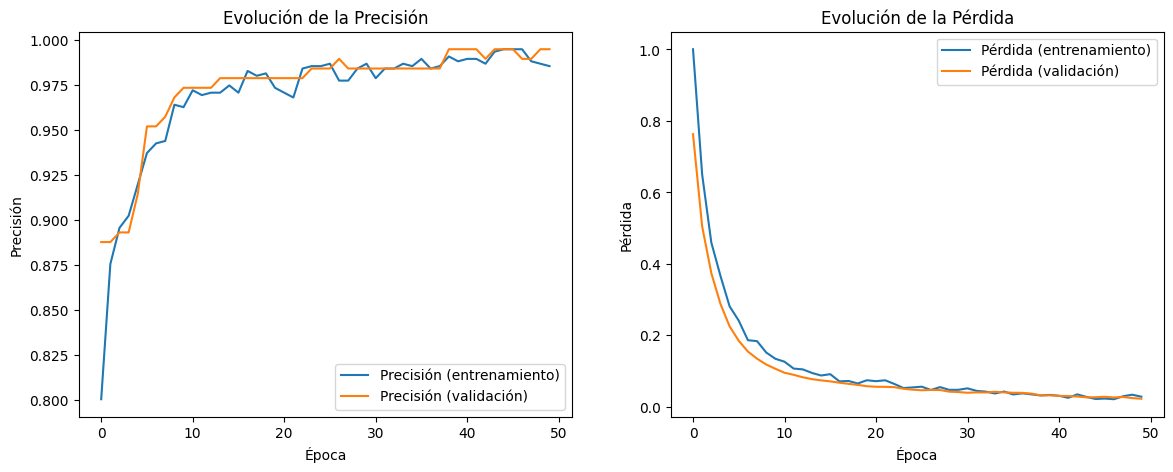

In [44]:

# Grafiquemos la precisión y la pérdida durante el entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Precisión
axes[0].plot(history.history['accuracy'], label='Precisión (entrenamiento)')
axes[0].plot(history.history['val_accuracy'], label='Precisión (validación)')
axes[0].set_title('Evolución de la Precisión')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Precisión')
axes[0].legend()

# Gráfico de Pérdida
axes[1].plot(history.history['loss'], label='Pérdida (entrenamiento)')
axes[1].plot(history.history['val_loss'], label='Pérdida (validación)')
axes[1].set_title('Evolución de la Pérdida')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida')
axes[1].legend()

plt.show()


In [45]:

# Evaluamos el modelo con el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Precisión en el conjunto de prueba: {test_accuracy * 100:.2f}%")
print(f"Pérdida en el conjunto de prueba: {test_loss:.4f}")


Precisión en el conjunto de prueba: 98.72%
Pérdida en el conjunto de prueba: 0.0278


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
--- Reporte de Clasificación ---
                           precision    recall  f1-score   support

      Desempeño Aceptable       0.71      0.83      0.77         6
          Desempeño Bueno       1.00      1.00      1.00       180
      Desempeño Excelente       1.00      1.00      1.00        42
Desempeño insatisfactorio       0.80      0.67      0.73         6

                 accuracy                           0.99       234
                macro avg       0.88      0.88      0.87       234
             weighted avg       0.99      0.99      0.99       234

--- Matriz de Confusión ---


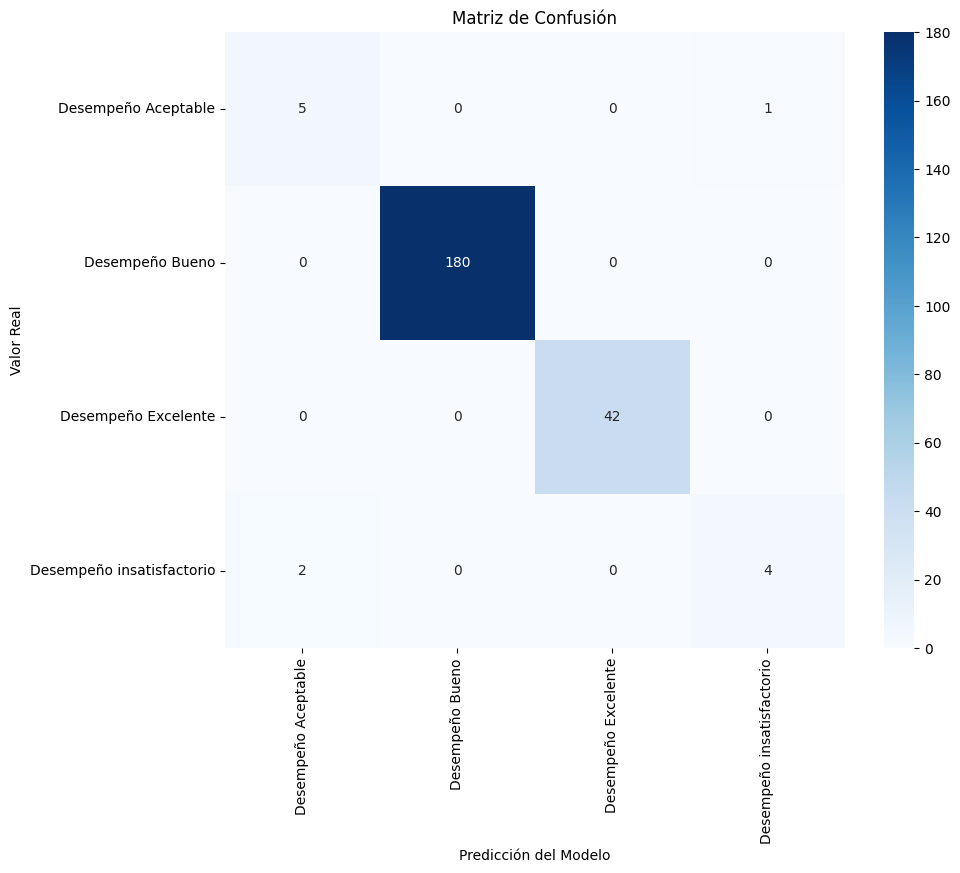

In [46]:

# Para un análisis más profundo, generamos un reporte de clasificación y una matriz de confusión

# Hacemos predicciones en el conjunto de prueba
y_pred = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred, axis=1)

# Reporte de Clasificación
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred_classes, target_names=target_encoder.classes_))

# Matriz de Confusión
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.title('Matriz de Confusión')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()



### ¿Cómo interpretar la Matriz de Confusión?

-   La **diagonal principal** (de arriba a la izquierda a abajo a la derecha) muestra todas las predicciones correctas. Nuestro objetivo es que estos números sean lo más altos posible.
-   Los números **fuera de la diagonal** son los errores. Por ejemplo, si en la fila "Desempeño Bueno" hay un número en la columna "Desempeño Excelente", significa que el modelo confundió un aula buena con una excelente.



## Paso 7: Usar el Modelo para una Nueva Predicción

¡Felicidades! Tenemos un modelo entrenado y evaluado. Ahora, ¿cómo lo usamos en la práctica? Vamos a simular que tenemos una **nueva aula virtual** y queremos predecir su desempeño.


In [47]:

# 1. Definimos los datos de una nueva aula (puedes cambiar estos valores)
new_aula = {
    'Momento': 3,
    'Tipo': 'VIRTUAL',
    'Tipo_Curso': 'PD',
    'Plantilla': 'INNOVAME',
    'Total_Alistamiento': 40,
    'Total_Ejecucion': 35,
    'Total_Curso': 75
}

# 2. Convertimos el diccionario a un DataFrame de Pandas
new_df = pd.DataFrame([new_aula])

print("Datos de la nueva aula:")
print(new_df)

# 3. Aplicamos el MISMO pre-procesamiento que antes
# Codificación
for col in categorical_features:
    new_df[col] = label_encoders[col].transform(new_df[col])

# Normalización
new_df_scaled = scaler.transform(new_df)

# 4. Hacemos la predicción
prediction_probs = model.predict(new_df_scaled)
predicted_class_index = np.argmax(prediction_probs, axis=1)[0]
predicted_class_name = target_encoder.inverse_transform([predicted_class_index])[0]

print("--------------------------------------")
print(f"-> La predicción para la nueva aula es: **{predicted_class_name}**")
print("--------------------------------------")

# Opcional: ver las probabilidades para cada clase
print("Probabilidades calculadas por el modelo:")
for i, class_name in enumerate(target_encoder.classes_):
    print(f"- {class_name}: {prediction_probs[0][i]*100:.2f}%")


Datos de la nueva aula:
   Momento     Tipo Tipo_Curso Plantilla  Total_Alistamiento  Total_Ejecucion  \
0        3  VIRTUAL         PD  INNOVAME                  40               35   

   Total_Curso  
0           75  
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
--------------------------------------
-> La predicción para la nueva aula es: **Desempeño Aceptable**
--------------------------------------
Probabilidades calculadas por el modelo:
- Desempeño Aceptable: 78.85%
- Desempeño Bueno: 6.60%
- Desempeño Excelente: 0.12%
- Desempeño insatisfactorio: 14.43%
